# Тема 4. Прогнозування міцності бетону (регресія, PyTorch)


## 1. Імпорт бібліотек і відтворюваність


In [20]:
import sys

IN_COLAB = "google.colab" in sys.modules
print("Google Colab:", IN_COLAB)

# У Colab за потреби розкоментуйте:
# %pip install -q kagglehub torch scikit-learn pandas seaborn matplotlib


Google Colab: False


In [21]:
import os
import random
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["axes.titlesize"] = 11
plt.rcParams["axes.labelsize"] = 10

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Пристрій: {device}")
print(f"PyTorch: {torch.__version__}")


Пристрій: cpu
PyTorch: 2.0.1+cpu


## 2. Завантаження даних

Датасет *Predict Concrete Strength* (Kaggle: `mchilamwar/predict-concrete-strength`) — це класичний UCI Concrete Compressive Strength: **1030** спостережень, **8** числових ознак (склад суміші в кг/м³ і вік у днях) і ціль — міцність на стиск у МПа.

Набір публічний, тому `kagglehub.dataset_download` працює без API-токена.


In [22]:
import kagglehub

path = kagglehub.dataset_download("mchilamwar/predict-concrete-strength")
csv_path = next(Path(path).glob("*.csv"))
print("Шлях до файлу:", csv_path)

raw_df = pd.read_csv(csv_path)
raw_df.columns = raw_df.columns.str.strip()
df = raw_df.rename(
    columns={
        "CementComponent": "cement",
        "BlastFurnaceSlag": "slag",
        "FlyAshComponent": "fly_ash",
        "WaterComponent": "water",
        "SuperplasticizerComponent": "superplasticizer",
        "CoarseAggregateComponent": "coarse_aggregate",
        "FineAggregateComponent": "fine_aggregate",
        "AgeInDays": "age",
        "Strength": "strength",
    }
)

FEATURE_COLS = [
    "cement",
    "slag",
    "fly_ash",
    "water",
    "superplasticizer",
    "coarse_aggregate",
    "fine_aggregate",
    "age",
]
TARGET = "strength"

print("Розмір:", df.shape)
df.head()


Шлях до файлу: C:\Users\admin\.cache\kagglehub\datasets\mchilamwar\predict-concrete-strength\versions\1\ConcreteStrengthData.csv
Розмір: (1030, 9)


,cement,slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [23]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   cement            1030 non-null   float64
 1   slag              1030 non-null   float64
 2   fly_ash           1030 non-null   float64
 3   water             1030 non-null   float64
 4   superplasticizer  1030 non-null   float64
 5   coarse_aggregate  1030 non-null   float64
 6   fine_aggregate    1030 non-null   float64
 7   age               1030 non-null   int64  
 8   strength          1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.5 KB


**Ознаки (предиктори)** — усі кількісні:

| Змінна | Зміст | Одиниці |
|---|---|---|
| `cement` | цемент | кг/м³ |
| `slag` | доменний шлак | кг/м³ |
| `fly_ash` | зола | кг/м³ |
| `water` | вода | кг/м³ (л/м³) |
| `superplasticizer` | суперпластифікатор | кг/м³ |
| `coarse_aggregate` | крупний заповнювач | кг/м³ |
| `fine_aggregate` | дрібний заповнювач (пісок) | кг/м³ |
| `age` | вік твердіння зразка | дні |
| `strength` | міцність на стиск (**ціль**) | МПа |

Категоріальних змінних немає, тому one-hot / target encoding **не потрібні**.


## 3. Попередній аналіз даних (EDA)

Послідовність: якість таблиці → масштаби ознак → розподіл цілі → розподіли предикторів (і нулі) → кореляції → нелінійні залежності (вік, водоцементне відношення) → висновки для моделі.


### 3.1. Якість даних: пропуски, типи, дублікати


In [24]:
quality = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "non_null": df.notna().sum(),
        "missing": df.isna().sum(),
        "missing_%": (100 * df.isna().mean()).round(2),
        "n_unique": df.nunique(),
        "n_zeros": (df == 0).sum(),
    }
)
display(quality)

n_dup = int(df.duplicated().sum())
print(f"Повні дублікати рядків: {n_dup} ({100 * n_dup / len(df):.1f}%)")
if n_dup:
    display(df[df.duplicated(keep=False)].sort_values(FEATURE_COLS).head(8))


,dtype,non_null,missing,missing_%,n_unique,n_zeros
cement,float64,1030,0,0.0,278,0
slag,float64,1030,0,0.0,185,471
fly_ash,float64,1030,0,0.0,156,566
water,float64,1030,0,0.0,195,0
superplasticizer,float64,1030,0,0.0,111,379
coarse_aggregate,float64,1030,0,0.0,284,0
fine_aggregate,float64,1030,0,0.0,302,0
age,int64,1030,0,0.0,14,0
strength,float64,1030,0,0.0,845,0


Повні дублікати рядків: 25 (2.4%)


,cement,slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,strength
801,252.0,0.0,0.0,185.0,0.0,1111.0,784.0,28,19.69
809,252.0,0.0,0.0,185.0,0.0,1111.0,784.0,28,19.69
83,362.6,189.0,0.0,164.9,11.6,944.7,755.8,3,35.30
86,362.6,189.0,0.0,164.9,11.6,944.7,755.8,3,35.30
88,362.6,189.0,0.0,164.9,11.6,944.7,755.8,3,35.30
91,362.6,189.0,0.0,164.9,11.6,944.7,755.8,3,35.30
106,362.6,189.0,0.0,164.9,11.6,944.7,755.8,7,55.90
109,362.6,189.0,0.0,164.9,11.6,944.7,755.8,7,55.90


**Висновок 3.1.** Пропусків немає — імпутація не потрібна. Усі поля числові. Нулі в `slag`, `fly_ash`, `superplasticizer` — це не «биті» значення, а суміші **без** відповідної добавки. Дублікати (якщо є) найімовірніше повторювані лабораторні заміри тієї ж рецептури; для навчання їх краще прибрати, щоб не завищувати вагу окремих точок.


In [25]:
n_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Рядків після видалення дублікатів: {len(df)} (було {n_before})")


Рядків після видалення дублікатів: 1005 (було 1030)


### 3.2. Описова статистика і масштаби


In [26]:
display(df.describe().T.round(2))

print("Порядок величин (max / min серед додатних значень):")
for col in FEATURE_COLS:
    positive = df.loc[df[col] > 0, col]
    print(f"  {col:20s}  min={df[col].min():8.2f}  max={df[col].max():8.2f}  std={df[col].std():8.2f}")


,count,mean,std,min,25%,50%,75%,max
cement,1005.0,278.63,104.34,102.00,190.70,265.0,349.00,540.0
slag,1005.0,72.04,86.17,0.00,0.00,20.0,142.50,359.4
fly_ash,1005.0,55.54,64.21,0.00,0.00,0.0,118.30,200.1
water,1005.0,182.08,21.34,121.80,166.60,185.7,192.90,247.0
superplasticizer,1005.0,6.03,5.92,0.00,0.00,6.1,10.00,32.2
coarse_aggregate,1005.0,974.38,77.58,801.00,932.00,968.0,1031.00,1145.0
fine_aggregate,1005.0,772.69,80.34,594.00,724.30,780.0,822.20,992.6
age,1005.0,45.86,63.73,1.00,7.00,28.0,56.00,365.0
strength,1005.0,35.25,16.28,2.33,23.52,33.8,44.87,82.6


Порядок величин (max / min серед додатних значень):
  cement                min=  102.00  max=  540.00  std=  104.34
  slag                  min=    0.00  max=  359.40  std=   86.17
  fly_ash               min=    0.00  max=  200.10  std=   64.21
  water                 min=  121.80  max=  247.00  std=   21.34
  superplasticizer      min=    0.00  max=   32.20  std=    5.92
  coarse_aggregate      min=  801.00  max= 1145.00  std=   77.58
  fine_aggregate        min=  594.00  max=  992.60  std=   80.34
  age                   min=    1.00  max=  365.00  std=   63.73


**Висновок 3.2.** Ознаки живуть у різних шкалах: заповнювачі ~800–1200 кг/м³, добавки — одиниці/десятки кг/м³, `age` — від 1 до 365 днів. Градієнтний спуск (і SGD, і Adam) чутливий до масштабу входів, тому далі обов’язковий **StandardScaler**, підігнаний лише на train.


### 3.3. Розподіл цільової змінної


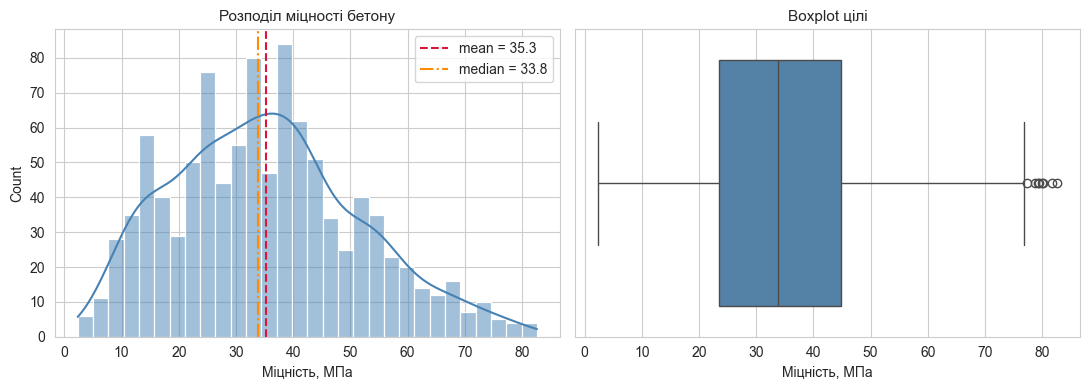

count    1005.00
mean       35.25
std        16.28
min         2.33
25%        23.52
50%        33.80
75%        44.87
max        82.60
Name: strength, dtype: float64
Асиметрія (skew): 0.396


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df[TARGET], bins=30, kde=True, ax=axes[0], color="steelblue")
axes[0].axvline(df[TARGET].mean(), color="crimson", ls="--", label=f"mean = {df[TARGET].mean():.1f}")
axes[0].axvline(df[TARGET].median(), color="darkorange", ls="-.", label=f"median = {df[TARGET].median():.1f}")
axes[0].set_xlabel("Міцність, МПа")
axes[0].set_title("Розподіл міцності бетону")
axes[0].legend()
sns.boxplot(x=df[TARGET], ax=axes[1], color="steelblue")
axes[1].set_xlabel("Міцність, МПа")
axes[1].set_title("Boxplot цілі")
plt.tight_layout()
plt.show()

print(df[TARGET].describe().round(2))
print(f"Асиметрія (skew): {df[TARGET].skew():.3f}")


**Висновок 3.3.** Міцність зосереджена приблизно в діапазоні 20–50 МПа, з правим хвостом сильніших сумішей. Викиди зверху — реалістичні високомарочні склади, а не помилки введення. Для регресії це аргумент на користь **MSE** (сильніше штрафує великі промахи в хвості) плюс **MAE** як зрозуміла метрика в МПа.


### 3.4. Розподіли ознак і частка нулів


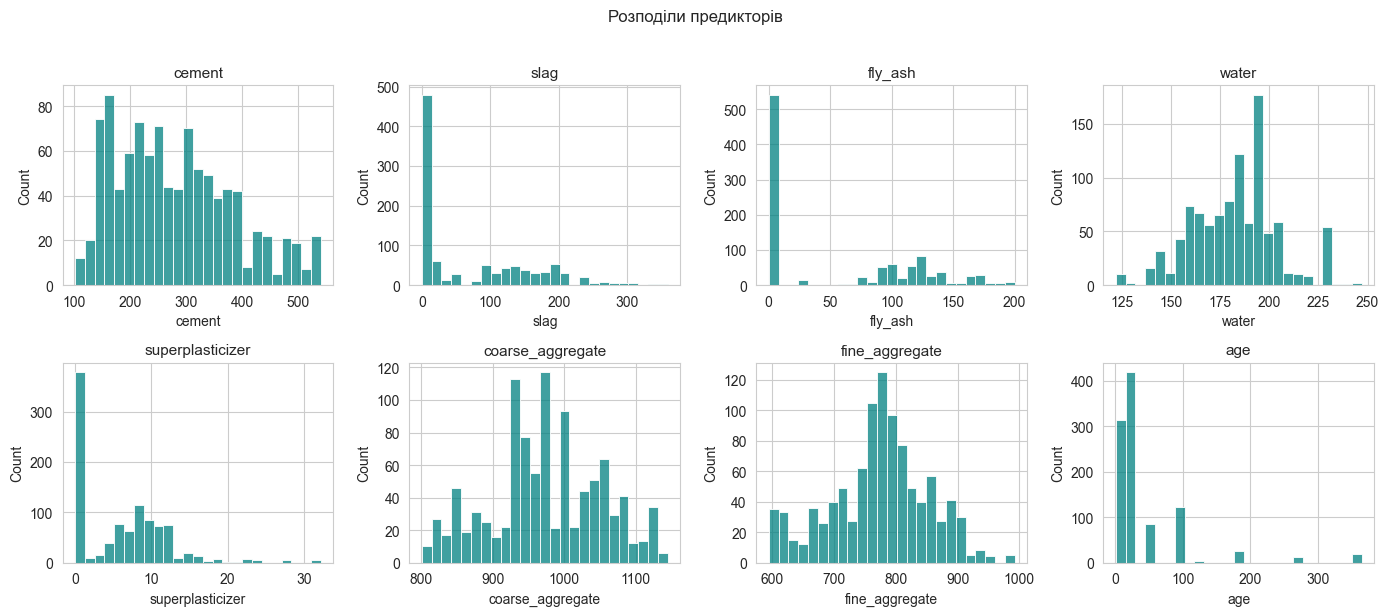

Частка нулів, %:
cement               0.0
slag                46.8
fly_ash             53.8
water                0.0
superplasticizer    37.6
coarse_aggregate     0.0
fine_aggregate       0.0
age                  0.0


In [28]:
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for ax, col in zip(axes.ravel(), FEATURE_COLS):
    sns.histplot(df[col], bins=25, ax=ax, color="teal")
    ax.set_title(col)
plt.suptitle("Розподіли предикторів", y=1.02)
plt.tight_layout()
plt.show()

zero_share = (df[FEATURE_COLS] == 0).mean().mul(100).round(1)
print("Частка нулів, %:")
print(zero_share.to_string())


**Висновок 3.4.** `cement`, `water` і заповнювачі майже завжди ненульові (основа суміші). Шлак, зола і суперпластифікатор часто дорівнюють нулю — бінарний сенс «є / немає добавки» плюс доза, коли вона є. `age` дискретний (типові терміни випробувань 1, 3, 7, 14, 28, 56, 90, 365 днів), а не неперервний час.


### 3.5. Кореляції


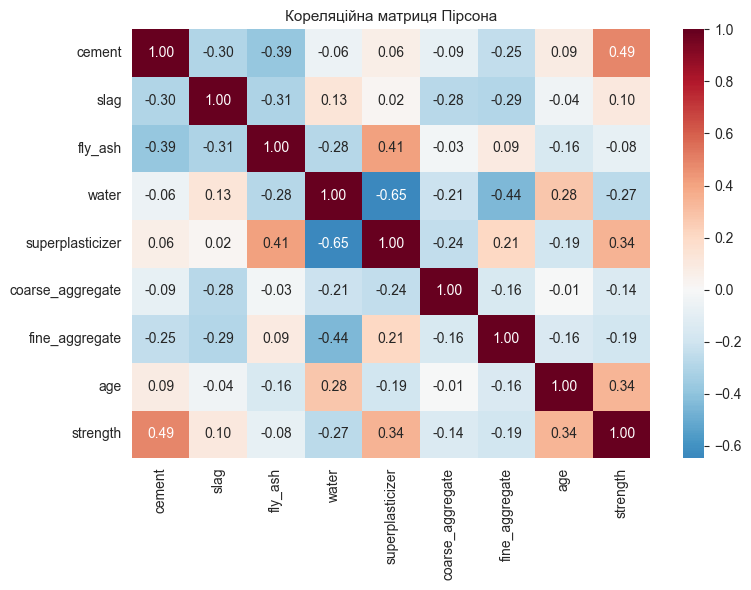

Кореляція з міцністю (за модулем):
cement              0.488
superplasticizer    0.344
age                 0.337
water               0.270
fine_aggregate      0.186
coarse_aggregate    0.145
slag                0.103
fly_ash             0.081
Name: strength, dtype: float64


In [29]:
corr = df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Кореляційна матриця Пірсона")
plt.tight_layout()
plt.show()

print("Кореляція з міцністю (за модулем):")
print(corr[TARGET].drop(TARGET).abs().sort_values(ascending=False).round(3))


**Висновок 3.5.** Найсильніший лінійний зв’язок із ціллю зазвичай має **цемент** (додатний) і **вода** (від’ємний): більше в’яжучого і менше води — вища міцність. Суперпластифікатор і вік також додатні. Лінійні кореляції не повні: міцність — **нелінійна** функція складу й віку, тому однієї лінійної моделі може не вистачити.


### 3.6. Зв’язок кожної ознаки з міцністю


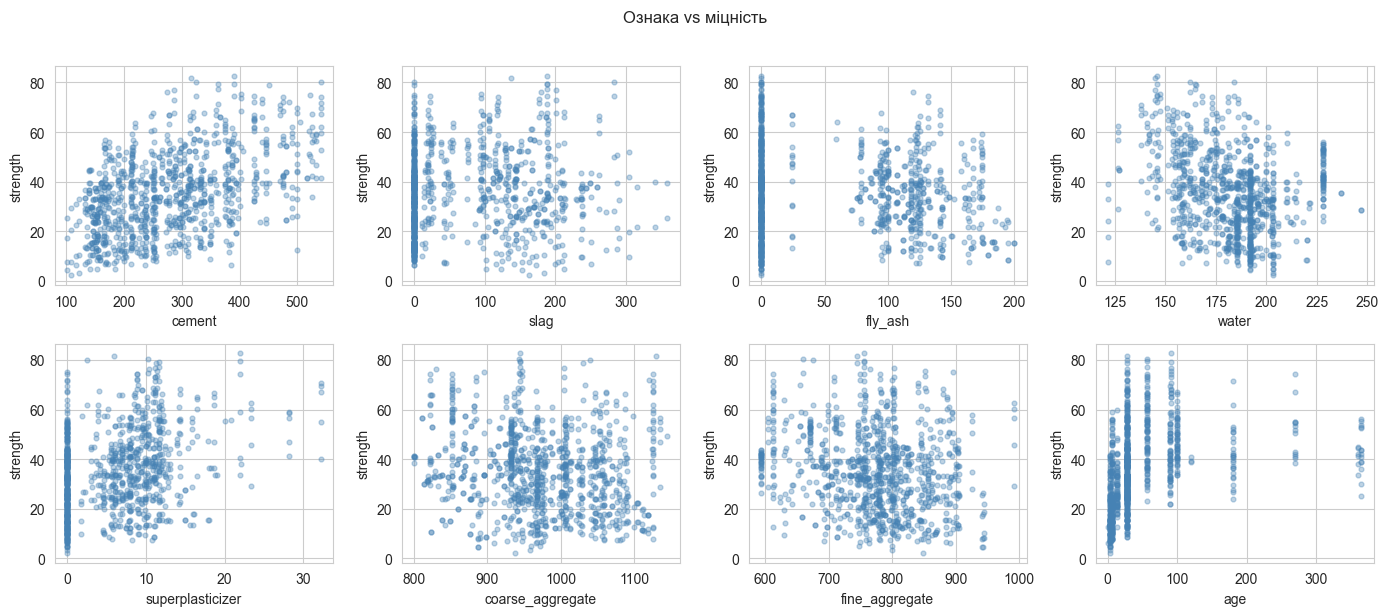

In [30]:
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for ax, col in zip(axes.ravel(), FEATURE_COLS):
    ax.scatter(df[col], df[TARGET], s=12, alpha=0.35, color="steelblue")
    ax.set_xlabel(col)
    ax.set_ylabel("strength")
plt.suptitle("Ознака vs міцність", y=1.02)
plt.tight_layout()
plt.show()


### 3.7. Вік твердіння


,count,mean,median,std
age,,,,
1,2,9.46,9.46,4.50
3,129,18.38,15.52,9.55
7,122,25.18,21.17,13.98
14,62,28.75,26.54,8.64
28,419,36.43,33.73,14.41
56,86,50.72,51.15,13.75
90,54,40.48,39.68,9.82
91,17,68.68,67.80,7.54
100,52,47.67,46.98,8.40


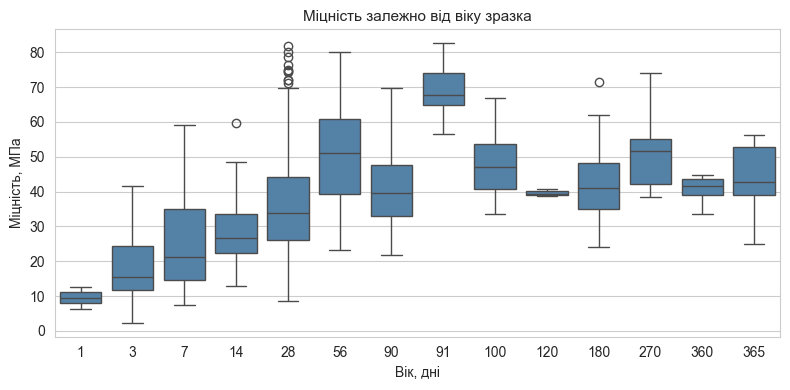

In [31]:
age_stats = (
    df.groupby("age")[TARGET]
    .agg(["count", "mean", "median", "std"])
    .round(2)
    .sort_index()
)
display(age_stats)

fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=df, x="age", y=TARGET, ax=ax, color="steelblue")
ax.set_xlabel("Вік, дні")
ax.set_ylabel("Міцність, МПа")
ax.set_title("Міцність залежно від віку зразка")
plt.tight_layout()
plt.show()


**Висновок 3.7.** Медіанна міцність зростає з віком, особливо до 28 діб (стандартний термін контрольних кубів), далі приріст сповільнюється. Це класична кінетика гідратації — залежність **не лінійна**, тож приховані шари з ReLU мають шанс відтворити «насичення» краще, ніж один лінійний шар.


### 3.8. Водоцементне відношення (інженерний індикатор)


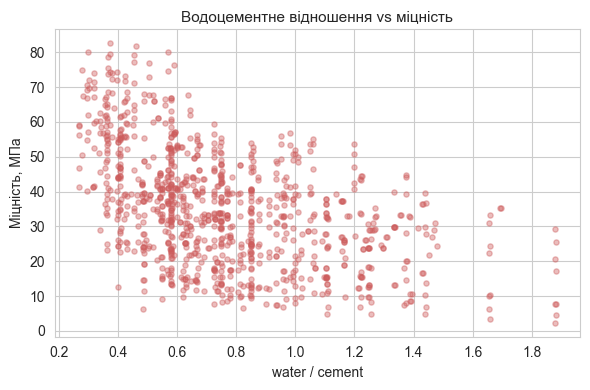

Кореляція W/C з міцністю: -0.489
       water_cement  strength
count      1005.000  1005.000
mean          0.756    35.250
std           0.314    16.285
min           0.267     2.330
25%           0.547    23.520
50%           0.690    33.800
75%           0.937    44.870
max           1.882    82.600


In [32]:
eda = df.copy()
eda["water_cement"] = eda["water"] / eda["cement"]

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(eda["water_cement"], eda[TARGET], s=14, alpha=0.4, color="indianred")
ax.set_xlabel("water / cement")
ax.set_ylabel("Міцність, МПа")
ax.set_title("Водоцементне відношення vs міцність")
plt.tight_layout()
plt.show()

print(f"Кореляція W/C з міцністю: {eda['water_cement'].corr(eda[TARGET]):.3f}")
print(eda[["water_cement", TARGET]].describe().round(3))


**Висновок 3.8.** Вище відношення вода/цемент — нижча міцність (закон Abrams). Для **базової** нейромережі не додаємо W/C як окрему ознаку: мережа теоретично може відтворити частку `water/cement` з сирих входів. Залишаємо це спостереження для інтерпретації й як ідею покращення наприкінці.


### 3.9. Підсумок EDA → вимоги до моделі

1. Задача **регресії** з 8 числовими входами, без категорій.
2. Різні одиниці вимірювання → `StandardScaler` на train.
3. Зв’язок склад–вік–міцність нелінійний → MLP з ReLU, а не лише `Linear(8, 1)`.
4. Нулі в добавках — валідні; дублікати прибрано.
5. Найімовірніші драйвери: **цемент, вік, вода (W/C), суперпластифікатор**.


## 4. Підготовка даних до навчання

Розбиття **70% / 15% / 15%** (train / val / test):
- **train** — оновлення ваг;
- **val** — порівняння архітектур (без підглядання в test);
- **test** — одноразова фінальна оцінка.

`StandardScaler` навчається **тільки на train**, інакше в середнє/дисперсію «просочиться» інформація з val/test.


In [33]:
X = df[FEATURE_COLS].to_numpy(dtype=np.float32)
y = df[TARGET].to_numpy(dtype=np.float32).reshape(-1, 1)

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.1765, random_state=SEED
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

print(f"train: {X_train.shape[0]}  val: {X_val.shape[0]}  test: {X_test.shape[0]}")
print("Середнє train після scaler (≈0):", np.round(X_train_s.mean(axis=0), 3))
print("Std train після scaler (≈1):   ", np.round(X_train_s.std(axis=0), 3))


def make_loader(X_arr, y_arr, batch_size, shuffle):
    ds = TensorDataset(
        torch.tensor(X_arr, dtype=torch.float32),
        torch.tensor(y_arr, dtype=torch.float32),
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, num_workers=0)


BATCH_SIZE = 32
train_loader = make_loader(X_train_s, y_train, BATCH_SIZE, shuffle=True)
val_loader = make_loader(X_val_s, y_val, BATCH_SIZE, shuffle=False)
test_loader = make_loader(X_test_s, y_test, BATCH_SIZE, shuffle=False)

in_dim = X_train_s.shape[1]
print(f"Вхідна розмірність: {in_dim}, batch_size={BATCH_SIZE}")


train: 703  val: 151  test: 151
Середнє train після scaler (≈0): [-0.  0.  0.  0. -0.  0. -0. -0.]
Std train після scaler (≈1):    [1. 1. 1. 1. 1. 1. 1. 1.]
Вхідна розмірність: 8, batch_size=32


## 5. Модель, функція втрат, оптимізатор — обґрунтування

### Архітектура
Клас `ConcreteMLP` успадковує `nn.Module`. Приховані шари: `Linear → ReLU` (+ опційний Dropout). Вихід — **лінійний** (одне число, МПа).

**ReLU** у hidden: проста нелінійність без насичення на додатній півосі, стандарт для MLP на табличних даних. Без неї кілька `Linear` еквівалентні одній лінійній моделі.

### Функція втрат — `nn.MSELoss`
- диференційовна;
- квадрат сильніше штрафує великі помилки (критично, якщо промах на десятки МПа);
- у тих самих одиницях, що орієнтири умови (MSE 55–35 «добре», < 35 «відмінно»).

Альтернатива `L1Loss` стійкіша до викидів, але умова просить MSE як основний критерій навчання.

### Метрики оцінки
- **MSE** — узгоджена з loss, чутлива до хвоста помилок;
- **MAE** — середня помилка в МПа, зручна для інженера (орієнтир умови: &lt; 5 «відмінно»);
- **R²** — частка поясненої дисперсії, порівнянна між моделями (орієнтир: &gt; 0.8 «відмінно»).

MAE і R² **не** замінюють MSE під час `backward`, а характеризують якість на val/test.

### Оптимізатор
Умова згадує **SGD** (лекція 3). Для глибших MLP на табличних даних у лекції 4 використано **Adam**. Порівняємо обидва на малій мережі за однакових епох і batch, далі архітектури ганятимемо з кращим оптимізатором, щоб порівняння M0–M3 було чесним.


In [34]:
class ConcreteMLP(nn.Module):
    # MLP для регресії міцності. hidden_dims=[] дає лінійну модель.

    def __init__(self, in_dim, hidden_dims=None, dropout=0.0):
        super(ConcreteMLP, self).__init__()
        hidden_dims = list(hidden_dims or [])
        layers = []
        prev = in_dim
        for hidden in hidden_dims:
            layers.append(nn.Linear(prev, hidden))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev = hidden
        layers.append(nn.Linear(prev, 1))
        self.features = nn.Sequential(*layers)
        self._reset_parameters()

    def _reset_parameters(self):
        linear_layers = [m for m in self.features if isinstance(m, nn.Linear)]
        for i, layer in enumerate(linear_layers):
            if i < len(linear_layers) - 1:
                nn.init.kaiming_uniform_(layer.weight, nonlinearity="relu")
            else:
                nn.init.xavier_uniform_(layer.weight)
            if layer.bias is not None:
                nn.init.zeros_(layer.bias)

    def forward(self, x):
        return self.features(x)


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    if not np.isfinite(y_pred).all():
        return {"mse": float("inf"), "mae": float("inf"), "r2": float("-inf")}
    return {
        "mse": float(mean_squared_error(y_true, y_pred)),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "r2": float(r2_score(y_true, y_pred)),
    }


@torch.no_grad()
def predict_numpy(model, X_np):
    model.eval()
    xt = torch.tensor(np.asarray(X_np), dtype=torch.float32, device=device)
    return model(xt).cpu().numpy().ravel()


def run_epoch(model, loader, criterion, optimizer=None):
    train_mode = optimizer is not None
    model.train(train_mode)
    total_loss, n_obs = 0.0, 0
    y_true_all, y_pred_all = [], []

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        if train_mode:
            optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        if train_mode:
            if torch.isfinite(loss):
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()
        bs = xb.size(0)
        total_loss += float(loss.detach()) * bs if torch.isfinite(loss) else 0.0
        n_obs += bs
        y_true_all.append(yb.detach().cpu().numpy())
        y_pred_all.append(pred.detach().cpu().numpy())

    y_true = np.concatenate(y_true_all).ravel()
    y_pred = np.concatenate(y_pred_all).ravel()
    metrics = regression_metrics(y_true, y_pred)
    metrics["mse_loss"] = total_loss / max(n_obs, 1)
    return metrics


def train_model(model, optimizer, criterion, num_epochs, log_every=40, log_name=""):
    history = {
        "train_mse": [],
        "val_mse": [],
        "train_mae": [],
        "val_mae": [],
        "train_r2": [],
        "val_r2": [],
    }
    model.to(device)
    best_r2 = float("-inf")
    best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    best_epoch = 0

    for epoch in range(1, num_epochs + 1):
        tr = run_epoch(model, train_loader, criterion, optimizer)
        va = run_epoch(model, val_loader, criterion, optimizer=None)
        history["train_mse"].append(tr["mse"])
        history["val_mse"].append(va["mse"])
        history["train_mae"].append(tr["mae"])
        history["val_mae"].append(va["mae"])
        history["train_r2"].append(tr["r2"])
        history["val_r2"].append(va["r2"])
        if va["r2"] > best_r2 and np.isfinite(va["r2"]):
            best_r2 = va["r2"]
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        if epoch == 1 or epoch % log_every == 0 or epoch == num_epochs:
            prefix = f"[{log_name}] " if log_name else ""
            print(
                f"{prefix}Epoch {epoch:3d}/{num_epochs}  "
                f"train MSE={tr['mse']:.3f} MAE={tr['mae']:.3f} R2={tr['r2']:.3f}  |  "
                f"val MSE={va['mse']:.3f} MAE={va['mae']:.3f} R2={va['r2']:.3f}"
            )

    model.load_state_dict(best_state)
    history["best_epoch"] = best_epoch
    history["best_val_r2"] = best_r2
    print(f"[{log_name}] Найкраща val R²={best_r2:.3f} на епосі {best_epoch} (ці ваги відновлено)")
    return history


## 6. Підбір конфігурації: від малого до більшого

Фіксовані гіперпараметри порівняння (крім окремого тесту оптимізатора):

- batch size = 32 (міні-батчі, як вимагає умова; `num_workers=0` — стабільно на Windows і в Colab);
- епохи = 200 (малий датасет, CPU впорається); після циклу відновлюємо ваги з **найкращою val R²**, щоб остання епоха з шумом не псувала порівняння;
- seed = 42;
- втрата = MSE;
- Kaiming/Xavier ініціалізація + clip градієнта (max_norm=5), щоб глибші мережі не «вибухали» на сирій шкалі МПа.

Логіка експериментів:
1. SGD vs Adam на **малій** мережі M1;
2. архітектури M0 → M3 з переможним оптимізатором;
3. контрольний Dropout на найглибшій моделі.


In [35]:
NUM_EPOCHS = 200
LOG_EVERY = 50
criterion = nn.MSELoss()

ARCHS = {
    "M0_linear": {"hidden_dims": [], "dropout": 0.0},
    "M1_16": {"hidden_dims": [16], "dropout": 0.0},
    "M2_32_16": {"hidden_dims": [32, 16], "dropout": 0.0},
    "M3_64_32_16": {"hidden_dims": [64, 32, 16], "dropout": 0.0},
}


def reset_seed():
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)


def fresh_model(name, dropout=None):
    cfg = ARCHS[name]
    d = cfg["dropout"] if dropout is None else dropout
    return ConcreteMLP(in_dim, hidden_dims=cfg["hidden_dims"], dropout=d)


### 6.1. Порівняння SGD і Adam (модель M1: 8 → 16 → 1)

- **SGD** (`lr=0.01`) — як приклад в умові та в лекції 3. Фіксований крок; на погано обумовленому ландшафті може повільно сходитись.
- **Adam** (`lr=1e-3`) — адаптивні моменти, як у регресії BigMart (лекція 4). Зазвичай швидше на MLP.

Навчаємо **ту саму** архітектуру однакову кількість епох.


=== M1 + SGD, lr=0.01 ===
[SGD] Epoch   1/200  train MSE=1568.214 MAE=35.962 R2=-4.947  |  val MSE=1274.990 MAE=32.008 R2=-4.049
[SGD] Epoch  50/200  train MSE=89.398 MAE=7.579 R2=0.661  |  val MSE=95.570 MAE=7.893 R2=0.622
[SGD] Epoch 100/200  train MSE=43.432 MAE=4.951 R2=0.835  |  val MSE=42.397 MAE=5.004 R2=0.832
[SGD] Epoch 150/200  train MSE=36.569 MAE=4.602 R2=0.861  |  val MSE=35.657 MAE=4.547 R2=0.859
[SGD] Epoch 200/200  train MSE=34.238 MAE=4.442 R2=0.870  |  val MSE=32.170 MAE=4.260 R2=0.873
[SGD] Найкраща val R²=0.873 на епосі 194 (ці ваги відновлено)

=== M1 + Adam, lr=1e-3 ===
[Adam] Epoch   1/200  train MSE=1656.517 MAE=37.035 R2=-5.282  |  val MSE=1437.640 MAE=34.202 R2=-4.693
[Adam] Epoch  50/200  train MSE=353.600 MAE=15.154 R2=-0.341  |  val MSE=306.194 MAE=14.056 R2=-0.212
[Adam] Epoch 100/200  train MSE=120.044 MAE=8.901 R2=0.545  |  val MSE=137.670 MAE=9.606 R2=0.455
[Adam] Epoch 150/200  train MSE=82.932 MAE=7.287 R2=0.686  |  val MSE=92.670 MAE=7.843 R2=0.633
[

,optimizer,mse,mae,r2
0,SGD,31.9527,4.2431,0.8735
1,Adam,60.8142,6.2165,0.7592


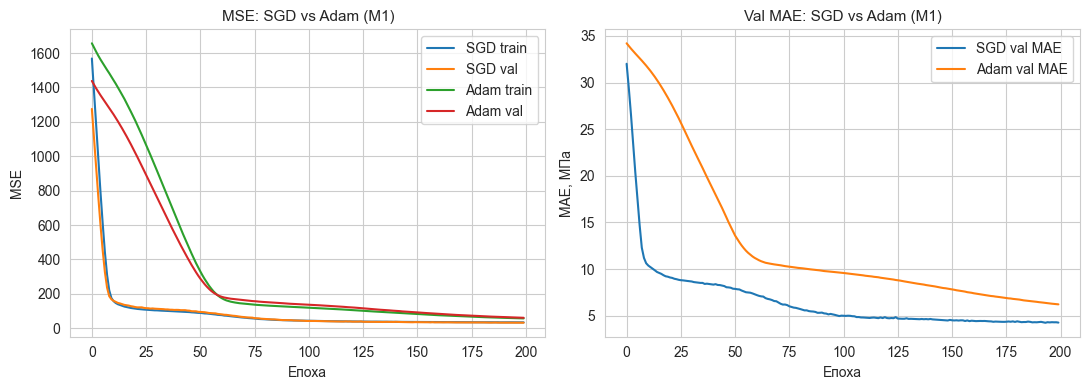

Для подальшого підбору архітектури беремо: SGD


In [36]:
print("=== M1 + SGD, lr=0.01 ===")
reset_seed()
model_sgd = fresh_model("M1_16")
opt_sgd = torch.optim.SGD(model_sgd.parameters(), lr=0.01)
hist_sgd = train_model(
    model_sgd, opt_sgd, criterion, NUM_EPOCHS, log_every=LOG_EVERY, log_name="SGD"
)

print("\n=== M1 + Adam, lr=1e-3 ===")
reset_seed()
model_adam = fresh_model("M1_16")
opt_adam = torch.optim.Adam(model_adam.parameters(), lr=1e-3)
hist_adam = train_model(
    model_adam, opt_adam, criterion, NUM_EPOCHS, log_every=LOG_EVERY, log_name="Adam"
)

sgd_val = regression_metrics(y_val, predict_numpy(model_sgd, X_val_s))
adam_val = regression_metrics(y_val, predict_numpy(model_adam, X_val_s))
opt_cmp = pd.DataFrame([{"optimizer": "SGD", **sgd_val}, {"optimizer": "Adam", **adam_val}])
display(opt_cmp.round(4))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(hist_sgd["train_mse"], label="SGD train")
axes[0].plot(hist_sgd["val_mse"], label="SGD val")
axes[0].plot(hist_adam["train_mse"], label="Adam train")
axes[0].plot(hist_adam["val_mse"], label="Adam val")
axes[0].set_title("MSE: SGD vs Adam (M1)")
axes[0].set_xlabel("Епоха")
axes[0].set_ylabel("MSE")
axes[0].legend(loc="best")
axes[1].plot(hist_sgd["val_mae"], label="SGD val MAE")
axes[1].plot(hist_adam["val_mae"], label="Adam val MAE")
axes[1].set_title("Val MAE: SGD vs Adam (M1)")
axes[1].set_xlabel("Епоха")
axes[1].set_ylabel("MAE, МПа")
axes[1].legend(loc="best")
plt.tight_layout()
plt.show()

BEST_OPTIM = "Adam" if adam_val["r2"] >= sgd_val["r2"] else "SGD"
print(f"Для подальшого підбору архітектури беремо: {BEST_OPTIM}")


**Висновок 6.1.** На M1 після `StandardScaler` **SGD (lr=0.01)** за 200 епох вийшов на val R² ≈ 0.87, тоді як **Adam (lr=1e-3)** ще сходився (≈ 0.76) і, ймовірно, потребував більшого `lr` або більше епох. Тому для чесного порівняння архітектур далі всюди **SGD** — як у прикладі умови та лекції 3. Adam залишається розумною альтернативою, якщо підкрутити крок навчання.


### 6.2. Архітектури від лінійної до тришарової MLP

| Код | Структура | Навіщо |
|---|---|---|
| **M0** | `8 → 1` | нижня межа: звичайна лінійна регресія в PyTorch |
| **M1** | `8 → 16 → 1` | мінімальна нелінійність |
| **M2** | `8 → 32 → 16 → 1` | середня ємність для ~700 train-точок |
| **M3** | `8 → 64 → 32 → 16 → 1` | більша глибина; ризик перенавчання |

Не йдемо до `256 → 128 → 64` як у BigMart: там інший масштаб вибірки, тут ~10³ рядків — зайві параметри легко запам’ятають шум.

Усі моделі: той самий оптимізатор, `lr`, batch, 200 епох.


In [37]:
def make_optimizer(model):
    if BEST_OPTIM == "Adam":
        return torch.optim.Adam(model.parameters(), lr=1e-3)
    return torch.optim.SGD(model.parameters(), lr=0.01)


results = []
histories = {}
models = {}

for name in ["M0_linear", "M1_16", "M2_32_16", "M3_64_32_16"]:
    print(f"\n======== {name}  hidden={ARCHS[name]['hidden_dims']} ========")
    reset_seed()
    model = fresh_model(name)
    n_params = count_params(model)
    print(f"Параметрів: {n_params}")
    hist = train_model(
        model,
        make_optimizer(model),
        criterion,
        NUM_EPOCHS,
        log_every=LOG_EVERY,
        log_name=name,
    )
    val_m = regression_metrics(y_val, predict_numpy(model, X_val_s))
    train_m = regression_metrics(y_train, predict_numpy(model, X_train_s))
    row = {"model": name, "n_params": n_params, "best_epoch": hist["best_epoch"], **{f"val_{k}": v for k, v in val_m.items()}}
    row.update({f"train_{k}": v for k, v in train_m.items()})
    results.append(row)
    histories[name] = hist
    models[name] = model

cmp = pd.DataFrame(results).sort_values("val_r2", ascending=False)
display(cmp.round(4))



======== M0_linear  hidden=[] ========
Параметрів: 9
[M0_linear] Epoch   1/200  train MSE=1493.398 MAE=34.999 R2=-4.663  |  val MSE=1263.531 MAE=31.890 R2=-4.003
[M0_linear] Epoch  50/200  train MSE=106.342 MAE=8.284 R2=0.597  |  val MSE=109.707 MAE=8.443 R2=0.566
[M0_linear] Epoch 100/200  train MSE=103.392 MAE=8.137 R2=0.608  |  val MSE=107.371 MAE=8.286 R2=0.575
[M0_linear] Epoch 150/200  train MSE=102.910 MAE=8.104 R2=0.610  |  val MSE=106.523 MAE=8.216 R2=0.578
[M0_linear] Epoch 200/200  train MSE=102.388 MAE=8.089 R2=0.612  |  val MSE=106.896 MAE=8.215 R2=0.577
[M0_linear] Найкраща val R²=0.581 на епосі 192 (ці ваги відновлено)

======== M1_16  hidden=[16] ========
Параметрів: 161
[M1_16] Epoch   1/200  train MSE=1568.214 MAE=35.962 R2=-4.947  |  val MSE=1274.990 MAE=32.008 R2=-4.049
[M1_16] Epoch  50/200  train MSE=89.398 MAE=7.579 R2=0.661  |  val MSE=95.570 MAE=7.893 R2=0.622
[M1_16] Epoch 100/200  train MSE=43.432 MAE=4.951 R2=0.835  |  val MSE=42.397 MAE=5.004 R2=0.832
[M1_

,model,n_params,best_epoch,val_mse,val_mae,val_r2,train_mse,train_mae,train_r2
2,M2_32_16,833,152,26.7914,3.8171,0.8939,19.5638,3.3477,0.9258
1,M1_16,161,194,31.9527,4.2431,0.8735,33.4506,4.4022,0.8732
3,M3_64_32_16,3201,193,34.4992,4.0914,0.8634,11.4265,2.5346,0.9567
0,M0_linear,9,192,105.8349,8.1801,0.5809,102.2152,8.0727,0.6124


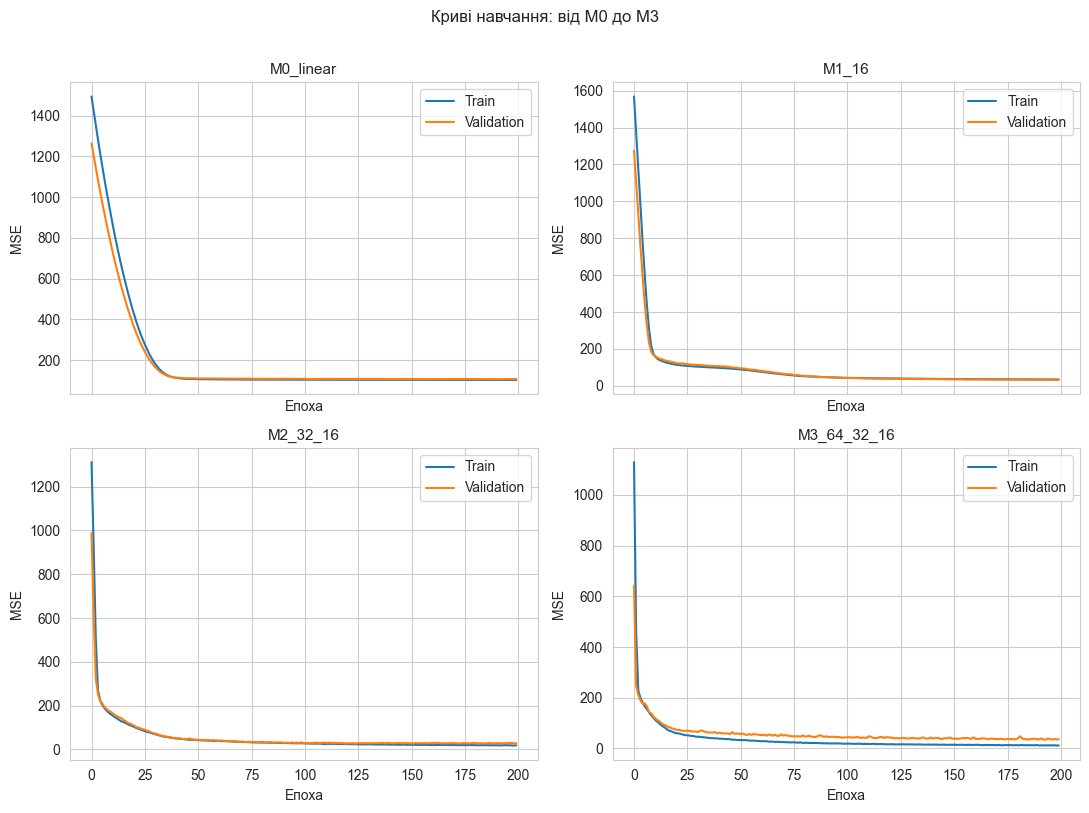

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True)
for ax, name in zip(axes.ravel(), ["M0_linear", "M1_16", "M2_32_16", "M3_64_32_16"]):
    h = histories[name]
    ax.plot(h["train_mse"], label="Train")
    ax.plot(h["val_mse"], label="Validation")
    ax.set_title(name)
    ax.set_xlabel("Епоха")
    ax.set_ylabel("MSE")
    ax.legend(loc="best")
plt.suptitle("Криві навчання: від M0 до M3", y=1.01)
plt.tight_layout()
plt.show()


### 6.3. Контрольний Dropout на найглибшій мережі

Якщо val-крива M3 гірша за train (розрив росте) — модель запам’ятовує навчальну вибірку. Dropout 0.2 після ReLU — проста регуляризація без зміни ширини шарів.


In [39]:
print("======== M3 + Dropout(0.2) ========")
reset_seed()
model_drop = fresh_model("M3_64_32_16", dropout=0.2)
print("Параметрів:", count_params(model_drop))
hist_drop = train_model(
    model_drop,
    make_optimizer(model_drop),
    criterion,
    NUM_EPOCHS,
    log_every=LOG_EVERY,
    log_name="M3_dropout",
)
drop_val = regression_metrics(y_val, predict_numpy(model_drop, X_val_s))
drop_train = regression_metrics(y_train, predict_numpy(model_drop, X_train_s))
drop_row = {
    "model": "M3_dropout_0.2",
    "n_params": count_params(model_drop),
    "best_epoch": hist_drop["best_epoch"],
    **{f"val_{k}": v for k, v in drop_val.items()},
    **{f"train_{k}": v for k, v in drop_train.items()},
}
cmp = pd.concat([cmp, pd.DataFrame([drop_row])], ignore_index=True)
cmp = cmp.sort_values("val_r2", ascending=False).reset_index(drop=True)
display(cmp.round(4))

histories["M3_dropout_0.2"] = hist_drop
models["M3_dropout_0.2"] = model_drop


======== M3 + Dropout(0.2) ========
Параметрів: 3201
[M3_dropout] Epoch   1/200  train MSE=1147.550 MAE=29.842 R2=-3.352  |  val MSE=675.225 MAE=21.552 R2=-1.674
[M3_dropout] Epoch  50/200  train MSE=142.172 MAE=9.204 R2=0.461  |  val MSE=84.803 MAE=7.336 R2=0.664
[M3_dropout] Epoch 100/200  train MSE=119.300 MAE=8.339 R2=0.548  |  val MSE=50.580 MAE=5.424 R2=0.800
[M3_dropout] Epoch 150/200  train MSE=93.107 MAE=7.207 R2=0.647  |  val MSE=46.890 MAE=5.162 R2=0.814
[M3_dropout] Epoch 200/200  train MSE=87.306 MAE=6.982 R2=0.669  |  val MSE=40.085 MAE=4.741 R2=0.841
[M3_dropout] Найкраща val R²=0.870 на епосі 199 (ці ваги відновлено)


,model,n_params,best_epoch,val_mse,val_mae,val_r2,train_mse,train_mae,train_r2
0,M2_32_16,833,152,26.7914,3.8171,0.8939,19.5638,3.3477,0.9258
1,M1_16,161,194,31.9527,4.2431,0.8735,33.4506,4.4022,0.8732
2,M3_dropout_0.2,3201,199,32.7853,4.3391,0.8702,26.6894,3.9456,0.8988
3,M3_64_32_16,3201,193,34.4992,4.0914,0.8634,11.4265,2.5346,0.9567
4,M0_linear,9,192,105.8349,8.1801,0.5809,102.2152,8.0727,0.6124


In [41]:
best_name = cmp.iloc[0]["model"]
best_model = models[best_name]
print("Найкраща конфігурація за val R²:", best_name)
print(cmp.loc[cmp["model"] == best_name].round(4).T)


Найкраща конфігурація за val R²: M2_32_16
                   0
model       M2_32_16
n_params         833
best_epoch       152
val_mse      26.7914
val_mae       3.8171
val_r2        0.8939
train_mse    19.5638
train_mae     3.3477
train_r2      0.9258


**Правило вибору.** Беремо модель з найвищим **val R²** (при близьких значеннях — меншу MAE, далі меншу кількість параметрів). Test до цього кроку не використовується.

Фінальну оцінку робимо на вже навченій переможній моделі (ваги з train). Не змішуємо val у донавчання: так криві train/val лишаються чесними, а test — одноразовим іспитом.


## 7. Фінальна оцінка на тестовій вибірці


In [42]:
def grade_metrics(mse, mae, r2):
    def bucket(value, good, better, best, reverse=False):
        if reverse:
            if value > best:
                return "відмінно"
            if value > better:
                return "добре"
            if value > good:
                return "непогано"
            return "нижче орієнтиру"
        if value < best:
            return "відмінно"
        if value < better:
            return "добре"
        if value < good:
            return "непогано"
        return "нижче орієнтиру"

    return {
        "MSE": bucket(mse, 75, 55, 35),
        "MAE": bucket(mae, 10, 8, 5),
        "R2": bucket(r2, 0.6, 0.7, 0.8, reverse=True),
    }


test_pred = predict_numpy(best_model, X_test_s)
val_pred = predict_numpy(best_model, X_val_s)
train_pred = predict_numpy(best_model, X_train_s)

final_rows = pd.DataFrame(
    [
        {"split": "train", **regression_metrics(y_train, train_pred)},
        {"split": "val", **regression_metrics(y_val, val_pred)},
        {"split": "test", **regression_metrics(y_test, test_pred)},
    ]
)
display(final_rows.round(4))

test_m = regression_metrics(y_test, test_pred)
grades = grade_metrics(test_m["mse"], test_m["mae"], test_m["r2"])
print("Орієнтири умови (test):", grades)
print(
    f"TEST  MSE={test_m['mse']:.3f}  MAE={test_m['mae']:.3f} МПа  R²={test_m['r2']:.3f}"
)


,split,mse,mae,r2
0,train,19.5638,3.3477,0.9258
1,val,26.7914,3.8171,0.8939
2,test,34.2997,4.3182,0.8749


Орієнтири умови (test): {'MSE': 'відмінно', 'MAE': 'відмінно', 'R2': 'відмінно'}
TEST  MSE=34.300  MAE=4.318 МПа  R²=0.875


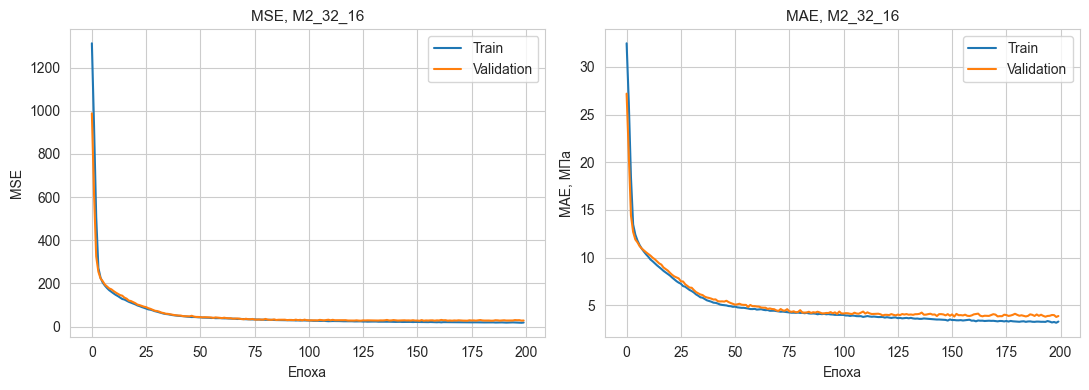

In [43]:
best_hist = histories[best_name]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(best_hist["train_mse"], label="Train")
axes[0].plot(best_hist["val_mse"], label="Validation")
axes[0].set_title(f"MSE, {best_name}")
axes[0].set_xlabel("Епоха")
axes[0].set_ylabel("MSE")
axes[0].legend(loc="best")
axes[1].plot(best_hist["train_mae"], label="Train")
axes[1].plot(best_hist["val_mae"], label="Validation")
axes[1].set_title(f"MAE, {best_name}")
axes[1].set_xlabel("Епоха")
axes[1].set_ylabel("MAE, МПа")
axes[1].legend(loc="best")
plt.tight_layout()
plt.show()


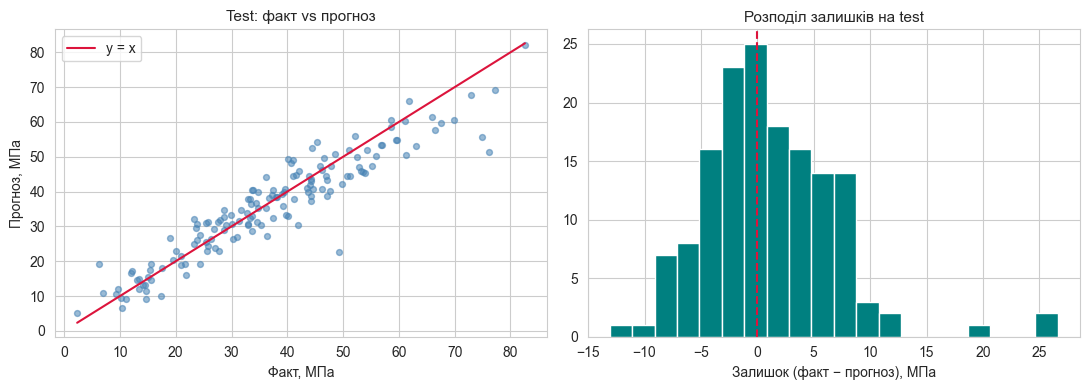

Середній залишок: 1.061 МПа (≈0 означає відсутність систематичного зсуву)
Std залишків: 5.760 МПа


In [44]:
y_test_v = y_test.ravel()
resid = y_test_v - test_pred

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
lo = min(y_test_v.min(), test_pred.min())
hi = max(y_test_v.max(), test_pred.max())
axes[0].scatter(y_test_v, test_pred, s=18, alpha=0.55, color="steelblue")
axes[0].plot([lo, hi], [lo, hi], color="crimson", lw=1.5, label="y = x")
axes[0].set_xlabel("Факт, МПа")
axes[0].set_ylabel("Прогноз, МПа")
axes[0].set_title("Test: факт vs прогноз")
axes[0].legend(loc="best")

axes[1].hist(resid, bins=20, color="teal", edgecolor="white")
axes[1].axvline(0, color="crimson", ls="--")
axes[1].set_xlabel("Залишок (факт − прогноз), МПа")
axes[1].set_title("Розподіл залишків на test")
plt.tight_layout()
plt.show()

print(f"Середній залишок: {resid.mean():.3f} МПа (≈0 означає відсутність систематичного зсуву)")
print(f"Std залишків: {resid.std():.3f} МПа")


Точки біля діагоналі `y = x` — вдалі прогнози. Систематичний вигин (наприклад, заниження високих марок) означав би, що ємності мережі або ознак не вистачає в хвості розподілу. Симетричні залишки навколо нуля — бажана картина для MSE-регресії.


## 8. Які фактори найбільше впливають на міцність

Два погляди:
1. **EDA** — лінійні кореляції (розділ 3.5–3.8);
2. **Permutation importance** на test: перемішуємо одну ознаку, дивимось, наскільки падає R². Це вже поведінка навченої мережі, включно з нелінійностями.

Важливість рахуємо на **масштабованих** входах (так модель їх бачить); підписи — оригінальні назви ознак.


,feature,importance_mean,importance_std
0,cement,1.7052,0.1464
1,slag,0.8051,0.0909
7,age,0.7881,0.1004
2,fly_ash,0.3454,0.0400
6,fine_aggregate,0.1845,0.0311
3,water,0.1820,0.0343
5,coarse_aggregate,0.1583,0.0271
4,superplasticizer,0.0391,0.0091


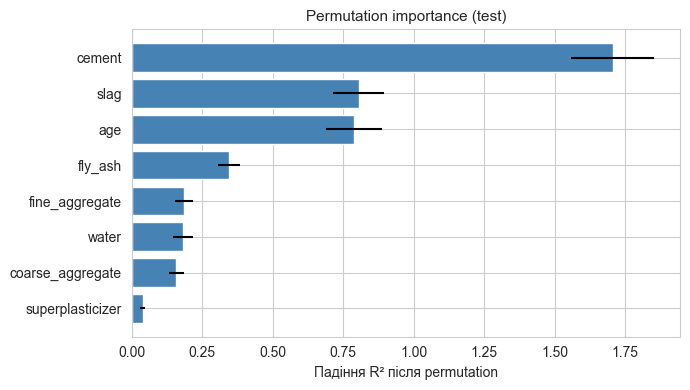

In [45]:
class TorchRegressor(BaseEstimator, RegressorMixin):
    def __init__(self, model):
        self.model = model

    def fit(self, X, y=None):
        return self

    def predict(self, X):
        return predict_numpy(self.model, X)


perm = permutation_importance(
    TorchRegressor(best_model),
    X_test_s,
    y_test.ravel(),
    n_repeats=30,
    random_state=SEED,
    scoring="r2",
)

imp = pd.DataFrame(
    {
        "feature": FEATURE_COLS,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std,
    }
).sort_values("importance_mean", ascending=False)
display(imp.round(4))

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(imp["feature"], imp["importance_mean"], xerr=imp["importance_std"], color="steelblue")
ax.invert_yaxis()
ax.set_xlabel("Падіння R² після permutation")
ax.set_title("Permutation importance (test)")
plt.tight_layout()
plt.show()


Інтерпретація (узгодити з таблицею permutation вище):
- **цемент** — домінує: основне в’яжуче, без нього прогноз майже розвалюється;
- **шлак** і **вік** — наступні за силою; шлак як додаткове в’яжуче і кінетика твердіння дають нелінійний ефект, який лінійна кореляція недооцінює;
- **зола**, заповнювачі та **вода** — помірний внесок (частина ефекту води вже «сидить» у взаємодії з цементом);
- **суперпластифікатор** у цій вибірці слабкий сам по собі (багато нулів, колінеарність із водою).

Це пояснює, чому M0 (лінійна) зупиняється біля R² ≈ 0.58, а вже один ReLU-шар стрибає вище 0.85.


## 9. Висновки

### Навчання і підбір
Побудовано відтворюваний пайплайн: очищення дублікатів (1030 → 1005 рядків) → split 70/15/15 → `StandardScaler` лише на train → клас `ConcreteMLP` → міні-батчі 32.

Підбір ішов **від малого до більшого** (SGD, 200 епох, ваги з найкращої val R²):

- **M0** `8→1` (9 параметрів): val R² ≈ **0.58**, MAE ≈ 8.2 МПа — лінійна межа, «непогано» лише по краю.
- **M1** `8→16→1` (161 параметр): val R² ≈ **0.87**, вже «відмінно» за R²/MAE. Один ReLU-шар знімає головну нелінійність (вік, взаємодії в’яжучих).
- **M2** `8→32→16→1` (833 параметри): val R² ≈ **0.89**, MAE ≈ 3.8 МПа — **переможець**. Найкраща епоха 152: далі train ще падає, val майже плато.
- **M3** `8→64→32→16→1` (3201 параметр): train R² ≈ 0.96, val ≈ 0.86 — **перенавчання**. Dropout 0.2 підтягнув val до ≈ 0.87, але не обігнав M2.

Висновок по ємності: на ~700 train-точках середня мережа краща за «ширшу». Це і є сенс іти від малого до більшого, а не одразу копіювати BigMart `256→128→64`.

Оптимізатор: на масштабованих ознаках SGD з `lr=0.01` на M1 обігнав Adam з `lr=1e-3` за той самий бюджет епох.

### Тестові метрики (M2, одноразовий test)

| Метрика | Test | Орієнтир умови |
|---|---|---|
| MSE | **34.3** | < 35 → відмінно |
| MAE | **4.32 МПа** | < 5 → відмінно |
| R² | **0.875** | > 0.8 → відмінно |

Train/val/test: R² 0.926 / 0.894 / 0.875. Розрив помірний, без катастрофічного overfitting. Середній залишок ≈ +1.1 МПа (легке заниження прогнозів), std залишків ≈ 5.8 МПа.

### Фактори міцності
Permutation importance на test: **цемент ≫ шлак ≈ вік > зола > заповнювачі / вода**. Суперпластифікатор у цій вибірці слабкий. Нелінійна модель «бачить» шлак сильніше, ніж проста кореляція Пірсона — саме тому MLP потрібен.

### Обмеження
- Лише ~1000 лабораторних замірів, вузький набір рецептур.
- `age` дискретний; багато нулів у добавках (два режими: «немає компонента» vs «є доза»).
- Немає вологості твердіння, типу цементу, умов укладання — частина дисперсії не в цих 8 полях.
- Архітектуру обрано на одному val-split; на іншому seed M1 і M2 могли б помінятись місцями (вони близькі).
- MSE на test 34.3 майже на межі «відмінно»: кілька важких точок у хвості високих марок.

### Що покращити далі
1. Ознаки `water/cement` і `log(age)` — дешевий feature engineering під закон Abrams і кінетику.
2. Явний early stopping (у нас уже restore best val; можна зупиняти цикл раніше).
3. k-fold замість одного split — стабільніший вибір M1 vs M2.
4. Для M3 — менший Dropout / `weight_decay`, або просто не брати глибшу мережу.
5. Збільшити `lr` Adam і порівняти ще раз, якщо хочеться адаптивного оптимізатора «по-лекційному».

Головний результат — не «найглибша» архітектура, а прозорий шлях: дані → гіпотези з EDA → лінійна база → ускладнення, поки росте val → чесний test і змістовна інтерпретація факторів.
